<div align="center">

# Laboratorio 5
## Minería de Textos y Análisis de Sentimiento

**Data Science · UVG 2026**

Iris Ayala &nbsp;·&nbsp; Jonathan Díaz &nbsp;·&nbsp; Anggie Quezada

</div>

---


# PARTE 1: CARGA DE DATOS Y PREPROCESAMIENTO

**Objetivo:** cargar el dataset de tweets, revisar su calidad (nulos, balance de clases) y aplicar una limpieza de texto estándar (minúsculas, sin URLs/menciones/números/stopwords) para dejarlo listo para el análisis de las Partes 2A y 2B.

## Importar Librerías

In [1]:
import pandas as pd
import numpy as np
import re
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')

import nltk
recursos_nltk = {
    'stopwords': 'corpora/stopwords',
    'vader_lexicon': 'sentiment/vader_lexicon.zip',
}
for recurso, ruta in recursos_nltk.items():
    try:
        nltk.data.find(ruta)
    except LookupError:
        nltk.download(recurso, quiet=True, raise_on_error=True)

print("Librerías y recursos de NLTK disponibles")

Librerías y recursos de NLTK disponibles


## Cargar Datos

In [2]:
df = pd.read_csv('train.csv')

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"\nDesastres (1): {(df['target']==1).sum()}")
print(f"No desastres (0): {(df['target']==0).sum()}")
print(f"\nPrimeras filas:")
df.head()

Dataset cargado: 7613 filas, 5 columnas

Desastres (1): 3271
No desastres (0): 4342

Primeras filas:


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


**Observación:** el dataset tiene 7,613 tweets y está moderadamente desbalanceado: 3,271 son desastres reales (43%) y 4,342 no lo son (57%). No es un desbalance severo, pero conviene tenerlo en cuenta más adelante al evaluar un clasificador (por ejemplo, usando F1-score o recall en vez de solo accuracy).

## Exploración Inicial

In [3]:
print("INFORMACIÓN GENERAL")
print("=" * 60)
df.info()

print("\n\nVALORES NULOS")
print("=" * 60)
print(df.isnull().sum())

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


VALORES NULOS
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


**Observación:** no hay nulos en `text` ni en `target`, así que el análisis de texto puede continuar sin imputaciones. `keyword` solo tiene 61 nulos (0.8%), pero `location` tiene 2,533 (33%) y además es texto libre sin estandarizar (la gente escribe ciudades, países, emojis o cosas inventadas), por lo que no se usará como variable confiable en este análisis.

## Preprocesamiento de Texto

Antes de analizar el vocabulario hay que normalizar el texto. La función `limpiar_tweet` aplica, en orden:

1. **Minúsculas** — para que "Fire" y "fire" cuenten como la misma palabra.
2. **Quitar URLs y menciones (@usuario)** — no aportan significado semántico sobre el evento.
3. **Quitar el símbolo `#` pero conservar la palabra del hashtag** — hashtags como `#earthquake` o `#wildfire` suelen ser justamente las palabras clave del tweet.
4. **Quitar números y puntuación** — reducen ruido sin perder información relevante para este análisis léxico.
5. **Quitar stopwords en inglés** (the, is, and, ...) — son muy frecuentes pero poco informativas para distinguir clases.

In [4]:
stop_words = set(stopwords.words('english'))

def limpiar_tweet(texto):
    """
    Limpia un tweet aplicando transformaciones:
    1. Minúsculas
    2. Quitar URLs
    3. Quitar menciones (@usuario)
    4. Quitar hashtags pero guardar palabra
    5. Quitar números
    6. Quitar puntuación
    7. Quitar espacios múltiples
    8. Quitar stopwords
    """
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+', '', texto)
    texto = re.sub(r'@\w+', '', texto)
    texto = re.sub(r'#', '', texto)
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^a-z\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    texto = ' '.join(palabras)
    
    return texto

print("Función de limpieza creada")

Función de limpieza creada


## Aplicar Limpieza

In [5]:
print("Limpiando tweets...")
df['text_cleaned'] = df['text'].apply(limpiar_tweet)

print("Ejemplos ANTES y DESPUÉS:")
print("\nANTES:")
print(df['text'].iloc[0])
print("\nDESPUES:")
print(df['text_cleaned'].iloc[0])

# Quitar tweets vacíos
vacios = (df['text_cleaned'].str.len() == 0).sum()
if vacios > 0:
    df = df[df['text_cleaned'].str.len() > 0].reset_index(drop=True)
    print(f"\nTweets vacíos eliminados: {vacios}")

print(f"\nDataset final: {len(df)} tweets")

Limpiando tweets...
Ejemplos ANTES y DESPUÉS:

ANTES:
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

DESPUES:
deeds reason earthquake may allah forgive us

Dataset final: 7613 tweets


**Observación:** el ejemplo muestra cómo un tweet crudo con hashtag y mayúsculas se reduce a sus palabras clave ("deeds reason earthquake may allah forgive us"). Ningún tweet quedó vacío tras la limpieza, por lo que se conservan los 7,613 registros originales para las siguientes partes.

## Guardar Dataset Limpio

In [6]:
df.to_csv('train_cleaned.csv', index=False)
print("Dataset limpio guardado como 'train_cleaned.csv'")

Dataset limpio guardado como 'train_cleaned.csv'


---
# PARTE 2A: ANÁLISIS EXPLORATORIO Y FRECUENCIA DE PALABRAS

**Objetivo:** Analizar qué palabras aparecen más en desastres vs no-desastres y visualizar con nubes de palabras.

## Importar Librerías Adicionales

In [7]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("Librerías de análisis importadas")

Librerías de análisis importadas


## Calcular Frecuencia de Palabras

In [8]:
# Tweets de DESASTRES
tweets_desastres = df[df['target'] == 1]['text_cleaned']
texto_desastres = ' '.join(tweets_desastres.values)
palabras_desastres = texto_desastres.split()
frecuencia_desastres = Counter(palabras_desastres)
top_15_desastres = frecuencia_desastres.most_common(15)

print("TOP 15 PALABRAS EN TWEETS DE DESASTRES")
print("=" * 50)
for i, (palabra, freq) in enumerate(top_15_desastres, 1):
    print(f"{i:2}. {palabra:15} -> {freq:5} veces")

# Tweets de NO-DESASTRES
tweets_no_desastres = df[df['target'] == 0]['text_cleaned']
texto_no_desastres = ' '.join(tweets_no_desastres.values)
palabras_no_desastres = texto_no_desastres.split()
frecuencia_no_desastres = Counter(palabras_no_desastres)
top_15_no_desastres = frecuencia_no_desastres.most_common(15)

print("\n\nTOP 15 PALABRAS EN TWEETS DE NO-DESASTRES")
print("=" * 50)
for i, (palabra, freq) in enumerate(top_15_no_desastres, 1):
    print(f"{i:2}. {palabra:15} -> {freq:5} veces")

TOP 15 PALABRAS EN TWEETS DE DESASTRES
 1. fire            ->   180 veces
 2. news            ->   138 veces
 3. via             ->   121 veces
 4. disaster        ->   117 veces
 5. california      ->   111 veces
 6. suicide         ->   110 veces
 7. police          ->   107 veces
 8. amp             ->   107 veces
 9. people          ->   105 veces
10. killed          ->    93 veces
11. like            ->    92 veces
12. pm              ->    89 veces
13. hiroshima       ->    89 veces
14. fires           ->    85 veces
15. storm           ->    85 veces


TOP 15 PALABRAS EN TWEETS DE NO-DESASTRES
 1. like            ->   253 veces
 2. im              ->   248 veces
 3. amp             ->   193 veces
 4. new             ->   170 veces
 5. get             ->   163 veces
 6. dont            ->   154 veces
 7. one             ->   128 veces
 8. body            ->   113 veces
 9. via             ->    99 veces
10. would           ->    97 veces
11. video           ->    96 veces
12. lov

**Observación:** en **desastres** predominan palabras concretas ligadas a eventos catastróficos: `fire` (180), `disaster` (117), `california` (111), `killed` (93), `storm` (85). En **no-desastres** predominan palabras conversacionales y coloquiales: `like` (253), `im` (248), `dont` (154), `love` (90) — típicas del habla cotidiana en redes sociales. Palabras como `via`, `amp`, `people` aparecen en ambos top-15, por lo que por sí solas no son buenas discriminantes; se necesita una medida relativa (ver la sección siguiente).

## Gráfico Comparativo: Top 15 Palabras

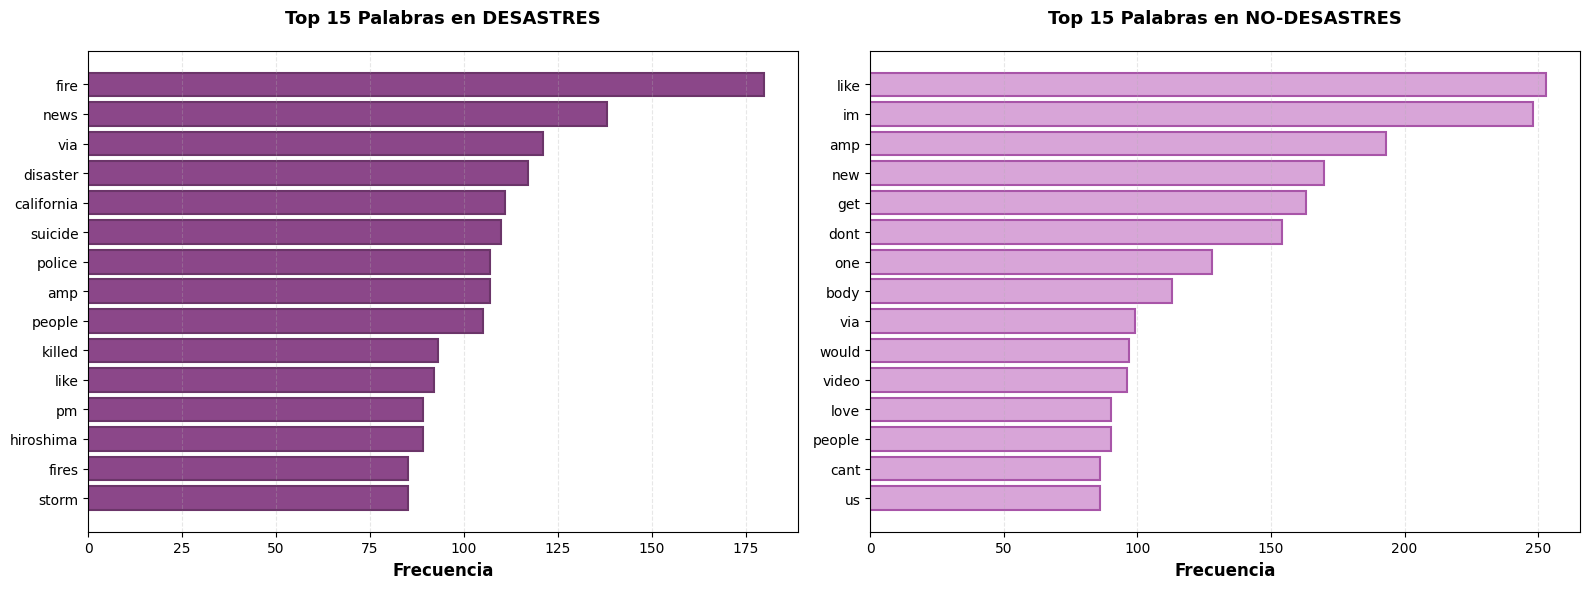

Gráfico guardado: img/frecuencia_palabras_comparacion.png


In [9]:
palabras_d = [p[0] for p in top_15_desastres]
freq_d = [p[1] for p in top_15_desastres]
palabras_nd = [p[0] for p in top_15_no_desastres]
freq_nd = [p[1] for p in top_15_no_desastres]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_desastres = '#8B4789'
color_no_desastres = '#D8A5D8'

axes[0].barh(palabras_d, freq_d, color=color_desastres, edgecolor='#6B3569', linewidth=1.5)
axes[0].set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Palabras en DESASTRES', fontsize=13, fontweight='bold', pad=20)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

axes[1].barh(palabras_nd, freq_nd, color=color_no_desastres, edgecolor='#A855A8', linewidth=1.5)
axes[1].set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
axes[1].set_title('Top 15 Palabras en NO-DESASTRES', fontsize=13, fontweight='bold', pad=20)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('img/frecuencia_palabras_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: img/frecuencia_palabras_comparacion.png")

El gráfico confirma visualmente lo anterior: las barras de la izquierda (desastres) están dominadas por sustantivos de eventos, mientras que las de la derecha (no-desastres) están dominadas por verbos/pronombres de uso cotidiano.

## Análisis de Palabras Discriminantes

In [10]:
print("\nPALABRAS QUE DISTINGUEN DESASTRES")
print("=" * 78)

# Los conteos observados usan 0 cuando una palabra está ausente. El ratio usa
# suavizado de Laplace (+1 en numerador y denominador) solo para evitar división
# por cero; nunca se presenta ese 1 como un conteo observado.
vocabulario = set(frecuencia_desastres) | set(frecuencia_no_desastres)
ratios = {}
for palabra in vocabulario:
    freq_d = frecuencia_desastres.get(palabra, 0)
    freq_nd = frecuencia_no_desastres.get(palabra, 0)
    ratio_suavizado = (freq_d + 1) / (freq_nd + 1)
    ratios[palabra] = {
        'desastres': freq_d,
        'no_desastres': freq_nd,
        'ratio_suavizado': ratio_suavizado,
    }

palabras_ordenadas = sorted(
    ratios.items(), key=lambda x: (x[1]['ratio_suavizado'], x[1]['desastres']), reverse=True
)

print(f"{'Palabra':15} {'Desastres':12} {'No-Desastres':15} {'Ratio +1':10}")
print("-" * 78)
for palabra, datos in palabras_ordenadas[:10]:
    print(f"{palabra:15} {datos['desastres']:12} {datos['no_desastres']:15} {datos['ratio_suavizado']:10.2f}")

print("\nPALABRAS QUE DISTINGUEN NO-DESASTRES")
print("=" * 78)
palabras_ordenadas_inverso = sorted(
    ratios.items(), key=lambda x: ((x[1]['no_desastres'] + 1) / (x[1]['desastres'] + 1), x[1]['no_desastres']), reverse=True
)
print(f"{'Palabra':15} {'No-Desastres':15} {'Desastres':12} {'Ratio +1':10}")
print("-" * 78)
for palabra, datos in palabras_ordenadas_inverso[:10]:
    ratio_inv = (datos['no_desastres'] + 1) / (datos['desastres'] + 1)
    print(f"{palabra:15} {datos['no_desastres']:15} {datos['desastres']:12} {ratio_inv:10.2f}")


PALABRAS QUE DISTINGUEN DESASTRES
Palabra         Desastres    No-Desastres    Ratio +1  
------------------------------------------------------------------------------
northern                  64               0      65.00
legionnaires              62               0      63.00
debris                    50               0      51.00
severe                    47               0      48.00
hiroshima                 89               1      45.00
migrants                  41               0      42.00
derailment                41               0      42.00
investigators             37               0      38.00
mh                        72               1      36.50
mosque                    35               0      36.00

PALABRAS QUE DISTINGUEN NO-DESASTRES
Palabra         No-Desastres    Desastres    Ratio +1  
------------------------------------------------------------------------------
bags                         43            1      22.00
bag                          40          

**Cómo leer la tabla:** `Desastres` y `No-Desastres` son conteos observados; una ausencia se muestra como **0**. `Ratio +1` aplica suavizado de Laplace únicamente al cociente: `(conteo_clase + 1) / (conteo_otra_clase + 1)`. Esta separación evita afirmar que una palabra ausente apareció una vez. Los ratios sirven como exploración, no como estimaciones causales; términos raros y eventos repetidos pueden producir valores extremos.

## Crear Nubes de Palabras

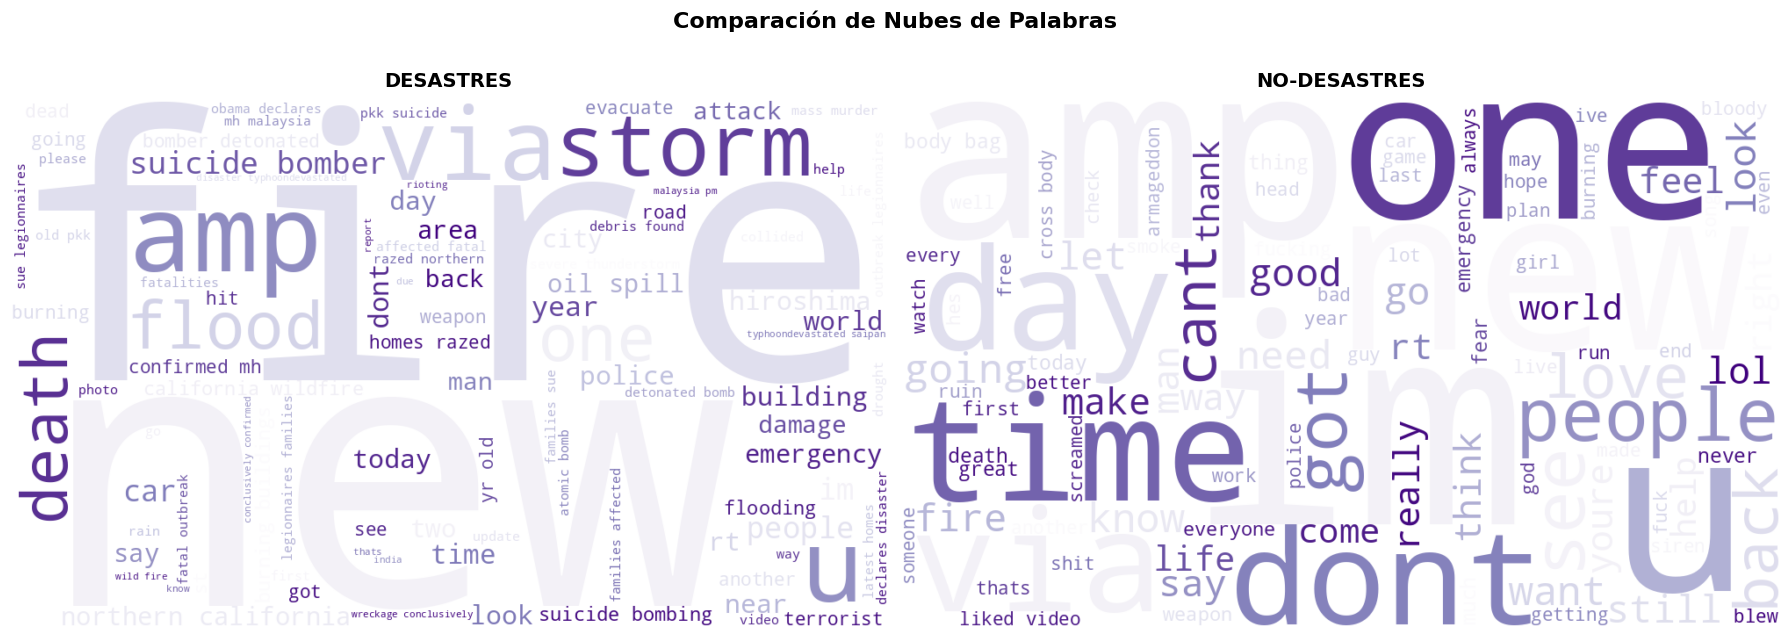

Gráfico guardado: img/wordcloud_comparacion.png


In [11]:
wordcloud_desastres = WordCloud(
    width=1000, height=600,
    background_color='white',
    colormap='Purples',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10,
    random_state=42
).generate(texto_desastres)

wordcloud_no_desastres = WordCloud(
    width=1000, height=600,
    background_color='white',
    colormap='Purples',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10,
    random_state=42
).generate(texto_no_desastres)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(wordcloud_desastres, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('DESASTRES', fontsize=14, fontweight='bold', pad=10)

axes[1].imshow(wordcloud_no_desastres, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('NO-DESASTRES', fontsize=14, fontweight='bold', pad=10)

plt.suptitle('Comparación de Nubes de Palabras', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('img/wordcloud_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: img/wordcloud_comparacion.png")

Las nubes de palabras resumen visualmente lo mismo: vocabulario de emergencia y lugares/eventos concretos en desastres, y lenguaje casual/emocional en no-desastres.

## Análisis de Palabras Compartidas vs Exclusivas

In [12]:
palabras_desastres_set = set(frecuencia_desastres.keys())
palabras_no_desastres_set = set(frecuencia_no_desastres.keys())

palabras_comunes = palabras_desastres_set & palabras_no_desastres_set
palabras_solo_desastres = palabras_desastres_set - palabras_no_desastres_set
palabras_solo_no_desastres = palabras_no_desastres_set - palabras_desastres_set

print("ANÁLISIS DE PALABRAS")
print("=" * 60)
print(f"Palabras únicas en DESASTRES: {len(palabras_desastres_set)}")
print(f"Palabras únicas en NO-DESASTRES: {len(palabras_no_desastres_set)}")
print(f"\nPalabras en AMBAS: {len(palabras_comunes)}")
print(f"Palabras SOLO en desastres: {len(palabras_solo_desastres)}")
print(f"Palabras SOLO en no-desastres: {len(palabras_solo_no_desastres)}")

print(f"\nEjemplos de palabras EXCLUSIVAS de desastres:")
print(sorted(list(palabras_solo_desastres))[:20])

print(f"\nEjemplos de palabras EXCLUSIVAS de no-desastres:")
print(sorted(list(palabras_solo_no_desastres))[:20])

ANÁLISIS DE PALABRAS
Palabras únicas en DESASTRES: 8006
Palabras únicas en NO-DESASTRES: 10372

Palabras en AMBAS: 3805
Palabras SOLO en desastres: 4201
Palabras SOLO en no-desastres: 6567

Ejemplos de palabras EXCLUSIVAS de desastres:
['aaaaaaallll', 'aaaaaand', 'aaarrrgghhh', 'aal', 'aampb', 'aan', 'aashiqui', 'abbswinston', 'abc', 'abcnews', 'abcs', 'aberystwythshrewsbury', 'abes', 'abha', 'abia', 'ableg', 'aboard', 'abomb', 'abombed', 'abouts']

Ejemplos de palabras EXCLUSIVAS de no-desastres:
['aaaa', 'aampw', 'aannnnd', 'aar', 'ab', 'abandoning', 'abbandoned', 'abbott', 'abbruchsimulator', 'abceyewitness', 'aberdeen', 'abject', 'abomination', 'abortions', 'abstract', 'absurdly', 'abused', 'academia', 'accepts', 'access']


**Observación:** de las 8,006 palabras únicas en desastres y las 10,372 en no-desastres, solo 3,805 se comparten entre ambas clases. Es decir, gran parte del vocabulario de cada clase es exclusivo suyo (4,201 palabras solo en desastres, 6,567 solo en no-desastres). Ese bajo solapamiento es una señal fuerte de separabilidad léxica, aunque hay que tomarlo con cautela: muchas de esas palabras "exclusivas" son ruido (nombres de usuario, errores tipográficos, hashtags mal cortados) más que patrones lingüísticos generalizables.

## Visualización: Palabras por Categoría

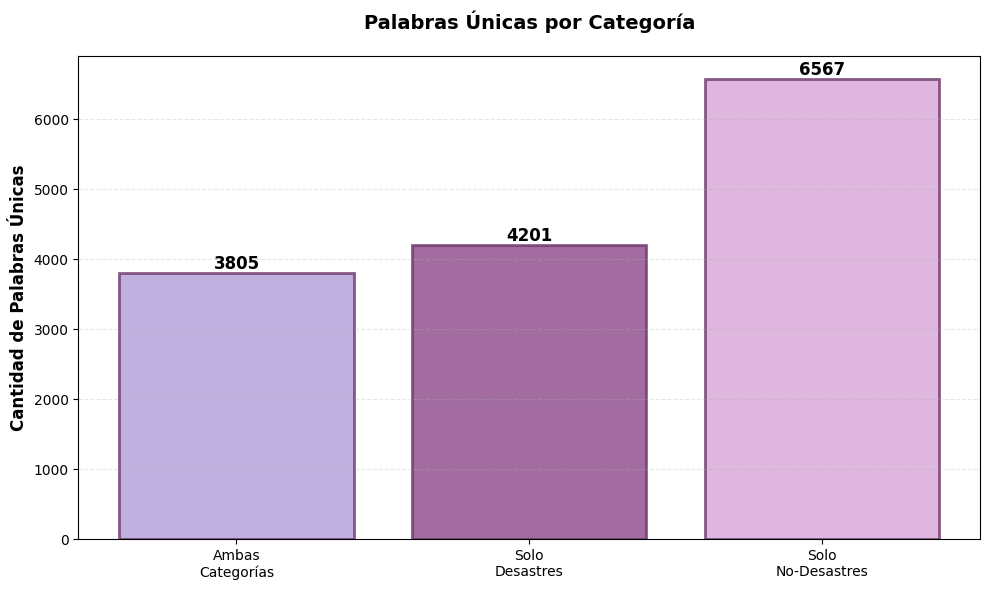

Gráfico guardado: img/palabras_analisis.png


In [13]:
categorias = ['Ambas\nCategorías', 'Solo\nDesastres', 'Solo\nNo-Desastres']
cantidades = [len(palabras_comunes), len(palabras_solo_desastres), len(palabras_solo_no_desastres)]
colores = ['#B19CD9', '#8B4789', '#D8A5D8']

fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(categorias, cantidades, color=colores, edgecolor='#6B3569', linewidth=2, alpha=0.8)

for barra, cantidad in zip(barras, cantidades):
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., altura,
            f'{int(cantidad)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Cantidad de Palabras Únicas', fontsize=12, fontweight='bold')
ax.set_title('Palabras Únicas por Categoría', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('img/palabras_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: img/palabras_analisis.png")

El gráfico deja ver que la mayoría del vocabulario (10,768 de 14,573 palabras únicas totales) pertenece a una sola clase, y solo una minoría (3,805) se comparte entre ambas.

---
# PARTE 2B: N-GRAMAS Y ANÁLISIS DE CONTEXTO

**Objetivo:** ir más allá de palabras sueltas y analizar secuencias de 2 y 3 palabras (bigramas y trigramas) para capturar el contexto en el que aparece cada término, y comparar la riqueza de vocabulario entre desastres y no-desastres.

## Preparar Textos por Categoría

In [14]:
# Colecciones separadas por categoría; se preserva cada límite de tweet.
tweets_desastres = df.loc[df['target'] == 1, 'text_cleaned']
tweets_no_desastres = df.loc[df['target'] == 0, 'text_cleaned']

print(f"Tweets de desastres: {len(tweets_desastres)}")
print(f"Tweets de no-desastres: {len(tweets_no_desastres)}")

Tweets de desastres: 3271
Tweets de no-desastres: 4342


**Decisión metodológica:** los textos se mantienen como documentos independientes. Concatenarlos antes de formar n-gramas crearía secuencias artificiales entre la última palabra de un tweet y la primera del siguiente. La agregación se hace únicamente después de generar los n-gramas dentro de cada tweet.

## Función para Generar N-gramas

In [15]:
def generar_ngramas_tweets(textos, n):
    """Genera n-gramas dentro de cada tweet y agrega sus conteos."""
    frecuencias = Counter()
    total = 0
    for texto in textos:
        palabras = texto.split()
        ngramas_tweet = [
            ' '.join(palabras[i:i+n])
            for i in range(len(palabras) - n + 1)
        ]
        frecuencias.update(ngramas_tweet)
        total += len(ngramas_tweet)
    return frecuencias, total


def tabla_top_ngramas(frecuencias, total, n=15):
    """Devuelve frecuencia observada y probabilidad relativa en el corpus."""
    return pd.DataFrame(
        [
            {'ngrama': termino, 'frecuencia': frecuencia, 'probabilidad': frecuencia / total}
            for termino, frecuencia in frecuencias.most_common(n)
        ]
    )


print("Función de n-gramas por tweet creada")

Función de n-gramas por tweet creada


## Generar y Analizar Bigramas en DESASTRES

In [16]:
frecuencia_bigramas_d, total_bigramas_d = generar_ngramas_tweets(tweets_desastres, 2)
top_15_bigramas_d = frecuencia_bigramas_d.most_common(15)
tabla_bigramas_d = tabla_top_ngramas(frecuencia_bigramas_d, total_bigramas_d)
print("TOP 15 BIGRAMAS EN TWEETS DE DESASTRES")
tabla_bigramas_d

TOP 15 BIGRAMAS EN TWEETS DE DESASTRES


,ngrama,frecuencia,probabilidad
0,suicide bomber,59,0.002179
1,northern california,41,0.001515
2,oil spill,38,0.001404
3,burning buildings,35,0.001293
4,suicide bombing,34,0.001256
5,california wildfire,34,0.001256
6,bomber detonated,30,0.001108
7,confirmed mh,29,0.001071
8,yr old,29,0.001071
9,homes razed,29,0.001071


**Observación:** los bigramas más frecuentes en desastres son fragmentos de eventos noticiosos concretos: `suicide bomber` (59), `suicide bombing` (34), `oil spill` (38), `california wildfire` (34), `burning buildings` (35). Confirma lo visto con palabras sueltas: el dataset agrupa tweets sobre incidentes específicos, no menciones genéricas de "desastre".

## Generar y Analizar Bigramas en NO-DESASTRES

In [17]:
frecuencia_bigramas_nd, total_bigramas_nd = generar_ngramas_tweets(tweets_no_desastres, 2)
top_15_bigramas_nd = frecuencia_bigramas_nd.most_common(15)
tabla_bigramas_nd = tabla_top_ngramas(frecuencia_bigramas_nd, total_bigramas_nd)
print("TOP 15 BIGRAMAS EN TWEETS DE NO-DESASTRES")
tabla_bigramas_nd

TOP 15 BIGRAMAS EN TWEETS DE NO-DESASTRES


,ngrama,frecuencia,probabilidad
0,cross body,38,0.001186
1,liked video,34,0.001062
2,full read,28,0.000874
3,body bag,27,0.000843
4,body bagging,23,0.000718
5,burning buildings,23,0.000718
6,looks like,21,0.000656
7,body bags,21,0.000656
8,reddit quarantine,21,0.000656
9,feel like,20,0.000624


**Observación:** en no-desastres destacan bigramas de un evento puntual y viral en Reddit ("reddit quarantine", "content policy", "quarantine offensive") y lenguaje coloquial ("looks like", "feel like", "dont know"). Llama la atención que `burning buildings` (23 veces) también aparezca aquí: probablemente por un uso figurado/metafórico fuera de un contexto real de desastre, lo que ilustra la ambigüedad que un clasificador tendría que resolver.

## Gráfico Comparativo: Bigramas

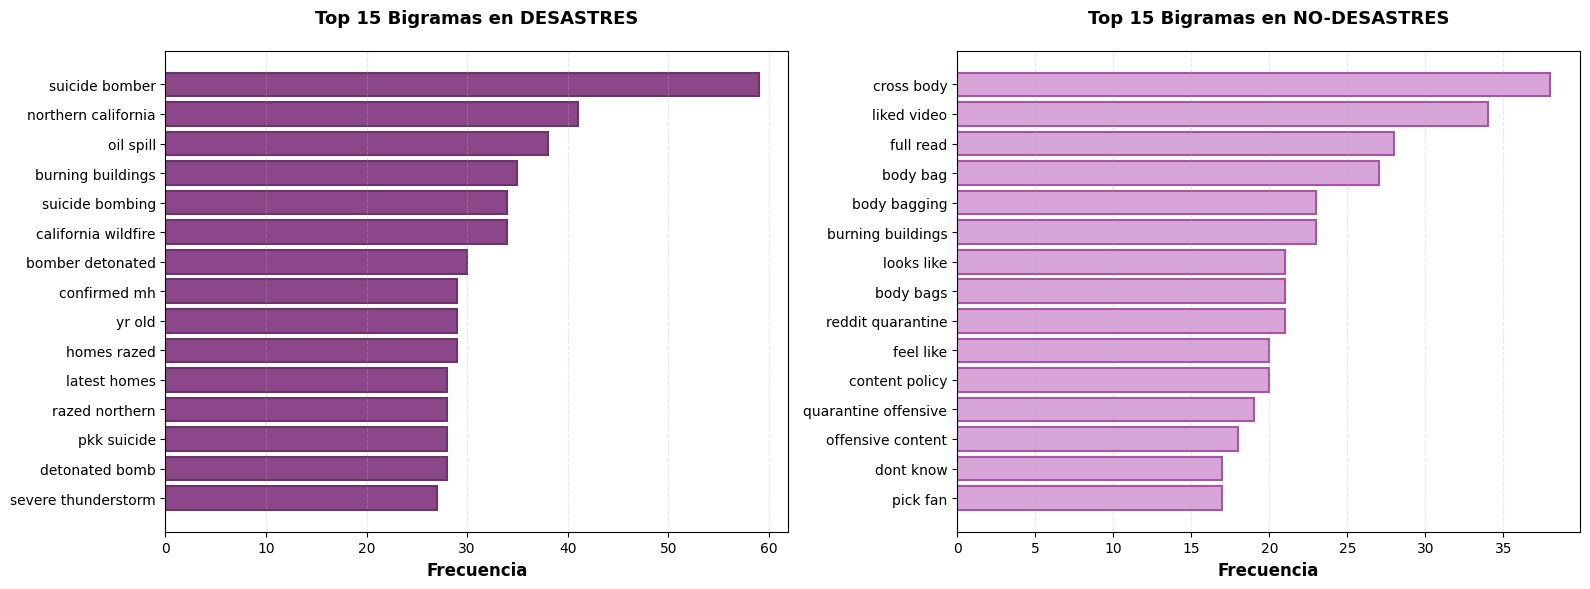

Gráfico guardado: img/bigramas_comparacion.png


In [18]:
bigramas_d_list = [b[0] for b in top_15_bigramas_d]
freq_bigramas_d = [b[1] for b in top_15_bigramas_d]

bigramas_nd_list = [b[0] for b in top_15_bigramas_nd]
freq_bigramas_nd = [b[1] for b in top_15_bigramas_nd]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_d = '#8B4789'
color_nd = '#D8A5D8'

axes[0].barh(bigramas_d_list, freq_bigramas_d, color=color_d, edgecolor='#6B3569', linewidth=1.5)
axes[0].set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Bigramas en DESASTRES', fontsize=13, fontweight='bold', pad=20)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

axes[1].barh(bigramas_nd_list, freq_bigramas_nd, color=color_nd, edgecolor='#A855A8', linewidth=1.5)
axes[1].set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
axes[1].set_title('Top 15 Bigramas en NO-DESASTRES', fontsize=13, fontweight='bold', pad=20)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('img/bigramas_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: img/bigramas_comparacion.png")

El gráfico visualiza la brecha temática: bigramas de eventos de emergencia a la izquierda vs. bigramas de una controversia puntual de Reddit y lenguaje casual a la derecha.

## Análisis de Bigramas Discriminantes

In [19]:
print("BIGRAMAS DISCRIMINANTES (CONTEOS OBSERVADOS Y RATIO SUAVIZADO)")
vocabulario_bigramas = set(frecuencia_bigramas_d) | set(frecuencia_bigramas_nd)
ratios_bigramas = {}
for bigrama in vocabulario_bigramas:
    freq_d = frecuencia_bigramas_d.get(bigrama, 0)
    freq_nd = frecuencia_bigramas_nd.get(bigrama, 0)
    ratios_bigramas[bigrama] = {
        'desastres': freq_d,
        'no_desastres': freq_nd,
        'ratio_d_mas_1': (freq_d + 1) / (freq_nd + 1),
        'ratio_nd_mas_1': (freq_nd + 1) / (freq_d + 1),
    }

top_d = sorted(ratios_bigramas.items(), key=lambda x: (x[1]['ratio_d_mas_1'], x[1]['desastres']), reverse=True)[:10]
top_nd = sorted(ratios_bigramas.items(), key=lambda x: (x[1]['ratio_nd_mas_1'], x[1]['no_desastres']), reverse=True)[:10]

pd.concat([
    pd.DataFrame([{'clase': 'Desastre', 'bigrama': b, **v} for b, v in top_d]),
    pd.DataFrame([{'clase': 'No desastre', 'bigrama': b, **v} for b, v in top_nd]),
], ignore_index=True)

BIGRAMAS DISCRIMINANTES (CONTEOS OBSERVADOS Y RATIO SUAVIZADO)


,clase,bigrama,desastres,no_desastres,ratio_d_mas_1,ratio_nd_mas_1
0,Desastre,suicide bomber,59,0,60.000000,0.016667
1,Desastre,northern california,41,0,42.000000,0.023810
2,Desastre,suicide bombing,34,0,35.000000,0.028571
3,Desastre,california wildfire,34,0,35.000000,0.028571
4,Desastre,bomber detonated,30,0,31.000000,0.032258
5,Desastre,confirmed mh,29,0,30.000000,0.033333
6,Desastre,homes razed,29,0,30.000000,0.033333
7,Desastre,yr old,29,0,30.000000,0.033333
8,Desastre,latest homes,28,0,29.000000,0.034483
9,Desastre,razed northern,28,0,29.000000,0.034483


La comparación usa la **unión** del vocabulario de ambas clases. Los conteos ausentes permanecen en 0 y el `+1` aparece solo en las columnas de ratio suavizado. Así sí pueden identificarse bigramas característicos de cualquiera de las dos clases sin sesgar la búsqueda hacia los más frecuentes de desastres.

## Generar y Analizar Trigramas en DESASTRES

In [20]:
frecuencia_trigramas_d, total_trigramas_d = generar_ngramas_tweets(tweets_desastres, 3)
top_15_trigramas_d = frecuencia_trigramas_d.most_common(15)
print("TOP 15 TRIGRAMAS EN TWEETS DE DESASTRES")
tabla_top_ngramas(frecuencia_trigramas_d, total_trigramas_d)

TOP 15 TRIGRAMAS EN TWEETS DE DESASTRES


,ngrama,frecuencia,probabilidad
0,suicide bomber detonated,30,0.001260
1,northern california wildfire,29,0.001218
2,latest homes razed,28,0.001176
3,homes razed northern,28,0.001176
4,pkk suicide bomber,28,0.001176
5,bomber detonated bomb,28,0.001176
6,razed northern california,27,0.001134
7,yr old pkk,27,0.001134
8,old pkk suicide,27,0.001134
9,families sue legionnaires,26,0.001092


**Observación:** varios trigramas de desastres son fragmentos consecutivos de una misma oración repetida muchas veces (`obama declares disaster` → `declares disaster typhoondevastated` → `disaster typhoondevastated saipan`), lo que indica que un solo tweet viral/retuiteado sobre un evento específico (un tifón en Saipán) domina el conteo. Hay que tenerlo presente: la alta frecuencia de un trigrama puede deberse a un único evento repetido y no a un patrón lingüístico general de "desastre".

## Generar y Analizar Trigramas en NO-DESASTRES

In [21]:
frecuencia_trigramas_nd, total_trigramas_nd = generar_ngramas_tweets(tweets_no_desastres, 3)
top_15_trigramas_nd = frecuencia_trigramas_nd.most_common(15)
print("TOP 15 TRIGRAMAS EN TWEETS DE NO-DESASTRES")
tabla_top_ngramas(frecuencia_trigramas_nd, total_trigramas_nd)

TOP 15 TRIGRAMAS EN TWEETS DE NO-DESASTRES


,ngrama,frecuencia,probabilidad
0,cross body bag,19,0.000685
1,reddit quarantine offensive,19,0.000685
2,quarantine offensive content,18,0.000648
3,pick fan army,17,0.000612
4,reddits new content,16,0.000576
5,new content policy,16,0.000576
6,chinas stock market,16,0.000576
7,stock market crash,16,0.000576
8,full read ebay,15,0.000540
9,ignition knock detonation,15,0.000540


**Observación:** ocurre el mismo patrón de "cadena de un solo tuit": los trigramas 1 a 5 encajan en una sola oración sobre el cambio de política de contenido de Reddit (`reddit quarantine offensive` → ... → `many horrible subreddits`), y los trigramas 7 a 9 en otra sobre la caída del mercado bursátil chino. Confirma que gran parte de la "riqueza" de trigramas proviene de un puñado de tweets retuiteados masivamente, no de mucha variedad de eventos distintos.

## Comparación de N-gramas (Uni/Bi/Trigramas)

In [22]:
frecuencia_unigramas_d, total_unigramas_d = generar_ngramas_tweets(tweets_desastres, 1)
frecuencia_unigramas_nd, total_unigramas_nd = generar_ngramas_tweets(tweets_no_desastres, 1)

datos_ngramas = {
    'Tipo': ['Unigramas (1)', 'Bigramas (2)', 'Trigramas (3)'],
    'En Desastres': [len(frecuencia_unigramas_d), len(frecuencia_bigramas_d), len(frecuencia_trigramas_d)],
    'En No-Desastres': [len(frecuencia_unigramas_nd), len(frecuencia_bigramas_nd), len(frecuencia_trigramas_nd)],
    'Total observado D': [total_unigramas_d, total_bigramas_d, total_trigramas_d],
    'Total observado ND': [total_unigramas_nd, total_bigramas_nd, total_trigramas_nd],
}

df_ngramas = pd.DataFrame(datos_ngramas)
df_ngramas

,Tipo,En Desastres,En No-Desastres,Total observado D,Total observado ND
0,Unigramas (1),8006,10372,30342,36371
1,Bigramas (2),19041,26901,27071,32029
2,Trigramas (3),18153,24700,23810,27757


**Observación:** al respetar los límites documentales, en desastres hay 8,006 unigramas, 19,041 bigramas y 18,153 trigramas únicos; en no-desastres hay 10,372, 26,901 y 24,700, respectivamente. Los bigramas amplían el vocabulario contextual, mientras que los trigramas únicos disminuyen porque muchos tweets cortos no producen secuencias de tres palabras. Los totales observados también disminuyen con `n`, como debe ocurrir al generar cada secuencia únicamente dentro de su tweet.

## Visualizar Riqueza de N-gramas

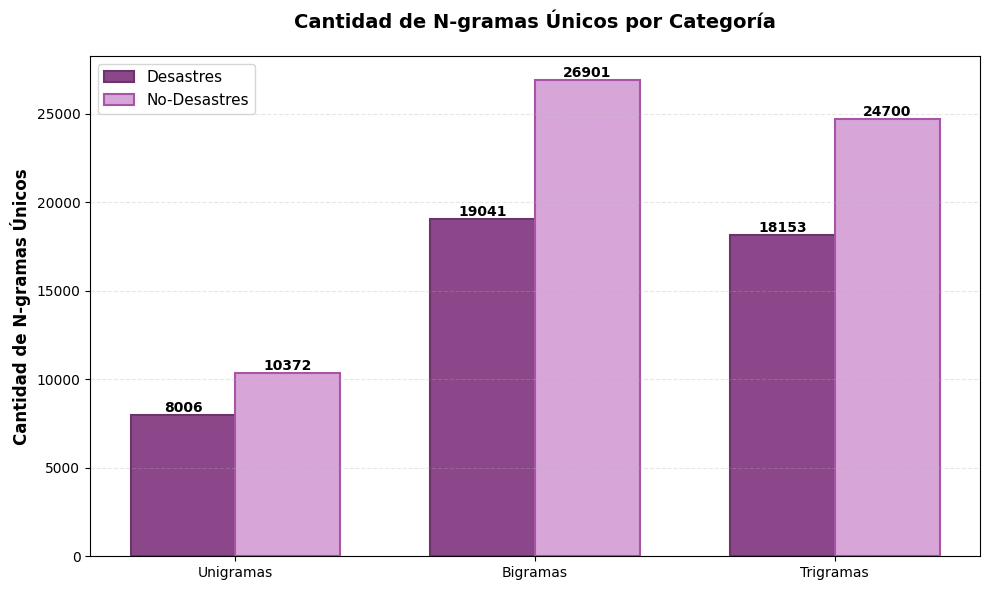

Gráfico guardado: img/ngramas_cantidad.png


In [23]:
import numpy as np

tipos = ['Unigramas', 'Bigramas', 'Trigramas']
desastres_counts = [
    len(frecuencia_unigramas_d),
    len(frecuencia_bigramas_d),
    len(frecuencia_trigramas_d)
]
no_desastres_counts = [
    len(frecuencia_unigramas_nd),
    len(frecuencia_bigramas_nd),
    len(frecuencia_trigramas_nd)
]

x = np.arange(len(tipos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

barras1 = ax.bar(x - width/2, desastres_counts, width, label='Desastres',
                  color='#8B4789', edgecolor='#6B3569', linewidth=1.5)
barras2 = ax.bar(x + width/2, no_desastres_counts, width, label='No-Desastres',
                  color='#D8A5D8', edgecolor='#A855A8', linewidth=1.5)

for barras in [barras1, barras2]:
    for barra in barras:
        altura = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2., altura,
                f'{int(altura)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Cantidad de N-gramas Únicos', fontsize=12, fontweight='bold')
ax.set_title('Cantidad de N-gramas Únicos por Categoría', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(tipos)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('img/ngramas_cantidad.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: img/ngramas_cantidad.png")

El gráfico resume la tendencia corregida: ambas clases tienen más bigramas y trigramas únicos que unigramas, pero los trigramas son menos diversos que los bigramas. La clase no-desastre tiene sistemáticamente más n-gramas únicos, en parte porque contiene más tweets.

---

## Conclusiones Generales

- **Preprocesamiento:** la limpieza (minúsculas, sin URLs/menciones/números/stopwords) no eliminó ningún tweet y dejó el corpus listo para el análisis léxico.
- **Separación léxica:** solo ~26% del vocabulario (3,805 de 14,573 palabras) se comparte entre desastres y no-desastres, y las palabras/bigramas más discriminantes de cada clase tienen sentido semántico claro (eventos de emergencia vs. lenguaje conversacional).
- **Los "desastres" del dataset son eventos concretos, no genéricos:** términos como `hiroshima`, `mh`, `legionnaires`, `suicide bomber` u `oil spill` muestran que gran parte de la señal proviene de un puñado de noticias puntuales (el vuelo de Malaysia Airlines, el brote de legionela, atentados, derrames), y varios trigramas de alta frecuencia son en realidad fragmentos de un mismo tuit viral repetido.
- **Riesgo para un futuro modelo:** un clasificador entrenado con este vocabulario podría aprender a reconocer estos eventos puntuales en vez de un patrón general de "lenguaje de desastre", por lo que conviene evaluarlo con tweets de eventos no vistos en entrenamiento para medir qué tanto generaliza.
- **Modelado:** estos hallazgos justifican usar TF-IDF con n-gramas 1-2, evaluado en la siguiente parte con un split estratificado y sin ajustar el vectorizador sobre prueba.

---
# PARTE 3: MODELOS DE CLASIFICACIÓN

**Objetivo:** entrenar varios modelos que clasifiquen un tweet como desastre real o no, usando el texto ya preprocesado, y elegir el mejor modelo según sus métricas.

## Importar Librerías de Modelado

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Separar Datos de Entrenamiento y Prueba

In [25]:
X = df['text_cleaned']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(X_train)} tweets")
print(f"Prueba: {len(X_test)} tweets")

Entrenamiento: 6090 tweets
Prueba: 1523 tweets


Se separa el 80% de los tweets para entrenar y el 20% para probar. Se usa `stratify` para que la proporción de desastres y no desastres sea la misma en ambos conjuntos, ya que el dataset está algo desbalanceado.

## Vectorización con TF-IDF

In [26]:
vectorizador = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

X_train_tfidf = vectorizador.fit_transform(X_train)
X_test_tfidf = vectorizador.transform(X_test)

print(f"Dimensiones de entrenamiento: {X_train_tfidf.shape}")
print(f"Dimensiones de prueba: {X_test_tfidf.shape}")

Dimensiones de entrenamiento: (6090, 5000)
Dimensiones de prueba: (1523, 5000)


Se usa TF-IDF con unigramas y bigramas, para que el modelo tome en cuenta el contexto de dos palabras juntas, como se vio en la Parte 2B. El vectorizador se ajusta solo con los datos de entrenamiento, para no filtrar información del conjunto de prueba.

## Entrenar Modelos

In [27]:
modelos = {
    'Naive Bayes': MultinomialNB(),
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'SVM Lineal': LinearSVC(random_state=42)
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)

print("Modelos entrenados")

Modelos entrenados


## Evaluar Modelos

In [28]:
resultados = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test_tfidf)
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.812213,0.860784,0.671254,0.754296
1,Regresión Logística,0.822718,0.846570,0.717125,0.776490
2,SVM Lineal,0.795141,0.765528,0.753823,0.759630


## Seleccionar el Mejor Modelo

In [29]:
mejor_fila = df_resultados.loc[df_resultados['F1-Score'].idxmax()]
nombre_mejor_modelo = mejor_fila['Modelo']
mejor_modelo = modelos[nombre_mejor_modelo]

print(f"Mejor modelo: {nombre_mejor_modelo}")
print(f"F1-Score: {mejor_fila['F1-Score']:.4f}")

Mejor modelo: Regresión Logística
F1-Score: 0.7765


Regresión Logística fue el mejor modelo, con el F1-Score más alto (0.7765), seguido por SVM Lineal (0.7596) y Naive Bayes (0.7543). Aunque Naive Bayes tuvo la mejor Precision (0.8608), su Recall fue el más bajo (0.6713), por lo que deja pasar más tweets de desastre real. Regresión Logística logra el mejor balance entre Precision (0.8466) y Recall (0.7171), lo cual explica su selección por F1-Score.

Cada modelo traza la frontera entre clases de forma distinta. Naive Bayes asume que las palabras son independientes entre sí, una simplificación fuerte para texto, por lo que es muy conservador: casi no se equivoca cuando predice desastre (Precision alta) pero deja pasar muchos casos reales (Recall bajo). Regresión Logística aprende un peso por cada palabra/bigrama sin asumir independencia, logrando detectar más desastres reales sin perder tanta precisión, de ahí el mejor equilibrio. Por eso se usa F1-Score para elegir: en este problema importan ambos errores (falsa alarma y desastre no detectado), así que no basta con optimizar solo accuracy o solo precision.

---
# PARTE 4: ANÁLISIS DE SENTIMIENTO (EJERCICIOS 8 Y 9)

**Objetivo:** clasificar el sentimiento sobre el tweet original con VADER, estudiar los extremos positivos y negativos, y comparar la negatividad entre categorías.

**Conclusión del ejercicio 8:** sí conviene conservar emoticones y puntuación para el análisis de sentimiento porque VADER los utiliza como señales afectivas. Por ello, el sentimiento se calcula a partir de `text` original, mientras que la clasificación temática utiliza `text_cleaned`.

In [30]:
from nltk.sentiment import SentimentIntensityAnalyzer
from scipy.stats import mannwhitneyu

analizador_sentimiento = SentimentIntensityAnalyzer()
scores_vader = df['text'].apply(analizador_sentimiento.polarity_scores).apply(pd.Series)
scores_vader = scores_vader.rename(columns={c: f'vader_{c}' for c in ['neg', 'neu', 'pos', 'compound']})
df = pd.concat([df, scores_vader], axis=1)
df['sentiment_label'] = np.select(
    [df['vader_compound'] >= 0.05, df['vader_compound'] <= -0.05],
    ['Positivo', 'Negativo'],
    default='Neutral',
)
df['negativity'] = df['vader_neg'].astype(float)

print("Distribución de sentimiento:")
df['sentiment_label'].value_counts().to_frame('tweets')

Distribución de sentimiento:


,tweets
sentiment_label,
Negativo,3707
Neutral,2013
Positivo,1893


### Ejercicios 9.1 y 9.2: extremos de sentimiento

VADER produce muchos empates porque es un método léxico. Para evitar una selección arbitraria o engañosa, el orden es determinista y explícito:

- **Más negativos:** mayor `vader_neg`, luego menor `vader_compound`, luego `id` ascendente.
- **Más positivos:** mayor `vader_pos`, luego mayor `vader_compound`, luego `id` ascendente.

Las tablas muestran exactamente 10 filas como solicita la consigna, pero no implican que el décimo tweet sea sustancialmente distinto de otros empatados fuera del corte.

In [31]:
columnas_extremos = ['id', 'text', 'target', 'target_label', 'vader_neg', 'vader_pos', 'vader_compound', 'sentiment_label']
df['target_label'] = df['target'].map({0: 'No desastre', 1: 'Desastre real'})

top_10_negativos = (
    df.sort_values(['vader_neg', 'vader_compound', 'id'], ascending=[False, True, True], kind='stable')
      .head(10)[columnas_extremos]
)
print("10 tweets más negativos")
top_10_negativos

10 tweets más negativos


,id,text,target,target_label,vader_neg,vader_pos,vader_compound,sentiment_label
7472,10689,wreck? wreck wreck wreck wreck wreck wreck wre...,0,No desastre,1.000,0.0,-0.9883,Negativo
3667,5221,Fatality!,0,No desastre,1.000,0.0,-0.6996,Negativo
3670,5224,fatality,0,No desastre,1.000,0.0,-0.6705,Negativo
5184,7400,Obliterated,0,No desastre,1.000,0.0,-0.4767,Negativo
1882,2703,Crushed,0,No desastre,1.000,0.0,-0.4215,Negativo
6015,8589,* Screams *,0,No desastre,1.000,0.0,-0.2960,Negativo
6372,9106,she's a suicide bomb,0,No desastre,0.885,0.0,-0.8271,Negativo
7185,10295,FUCK NUCLEAR WEAPON,0,No desastre,0.851,0.0,-0.6908,Negativo
900,1302,Damn bloody hot,0,No desastre,0.848,0.0,-0.6808,Negativo
3696,5259,Fatality ????,0,No desastre,0.845,0.0,-0.7550,Negativo


In [32]:
top_10_positivos = (
    df.sort_values(['vader_pos', 'vader_compound', 'id'], ascending=[False, False, True], kind='stable')
      .head(10)[columnas_extremos]
)
print("10 tweets más positivos")
top_10_positivos

10 tweets más positivos


,id,text,target,target_label,vader_neg,vader_pos,vader_compound,sentiment_label
4758,6769,@Benji_Devos thanks thanks :3,0,No desastre,0.0,0.901,0.8442,Positivo
5382,7680,@panic awesome thanks.,0,No desastre,0.0,0.875,0.7906,Positivo
6140,8759,Super sweet and beautiful :) https://t.co/TUi9...,0,No desastre,0.0,0.873,0.9300,Positivo
433,628,@local_arsonist LMFAO,0,No desastre,0.0,0.809,0.6408,Positivo
16,24,I love fruits,0,No desastre,0.0,0.808,0.6369,Positivo
22,33,Love skiing,0,No desastre,0.0,0.808,0.6369,Positivo
645,935,@Shayoly yes I love it,0,No desastre,0.0,0.775,0.7845,Positivo
1723,2486,We're happily collided :),0,No desastre,0.0,0.767,0.7650,Positivo
28,40,Cooool :),0,No desastre,0.0,0.750,0.4588,Positivo
6965,9990,@tsunami_esh ESH PLEASE OKAY!,0,No desastre,0.0,0.749,0.7147,Positivo


### Ejercicio 9.3: ¿los desastres son más negativos?

Se compara `negativity` entre `target=1` y `target=0`. Como la puntuación VADER está acotada, contiene muchos ceros y no se presupone normalidad, se usa **Mann–Whitney U bilateral**. La prueba evalúa si las distribuciones difieren; no prueba causalidad ni que cada tweet de desastre sea más negativo. Además del *p-value*, se reporta el tamaño de efecto de rango-biserial: `2U/(n1*n0)-1`, donde valores cercanos a 0 indican una diferencia pequeña.

In [33]:
neg_d = df.loc[df['target'] == 1, 'negativity']
neg_nd = df.loc[df['target'] == 0, 'negativity']

tabla_negatividad = df.groupby('target_label')['negativity'].agg(
    n='count', media='mean', mediana='median', desviacion='std', q25=lambda s: s.quantile(.25), q75=lambda s: s.quantile(.75)
)
u_stat, p_value = mannwhitneyu(neg_d, neg_nd, alternative='two-sided')
efecto_rb = 2 * u_stat / (len(neg_d) * len(neg_nd)) - 1

display(tabla_negatividad)
print(f"Mann–Whitney U bilateral: U={u_stat:.1f}, p-value={p_value:.6g}")
print(f"Tamaño de efecto rango-biserial: {efecto_rb:.4f}")
if p_value < 0.05:
    direccion = 'mayor' if neg_d.mean() > neg_nd.mean() else 'menor'
    print(f"Conclusión: hay evidencia estadística de una diferencia; la negatividad media es {direccion} en desastres.")
else:
    print("Conclusión: no hay evidencia suficiente de una diferencia entre categorías al nivel 0.05.")
print("La relevancia práctica debe juzgarse con el tamaño del efecto, no solo con significancia.")

,n,media,mediana,desviacion,q25,q75
target_label,,,,,,
Desastre real,3271,0.173582,0.157,0.167870,0.0,0.294
No desastre,4342,0.132318,0.088,0.159648,0.0,0.231


Mann–Whitney U bilateral: U=8141444.5, p-value=4.00854e-30
Tamaño de efecto rango-biserial: 0.1465
Conclusión: hay evidencia estadística de una diferencia; la negatividad media es mayor en desastres.
La relevancia práctica debe juzgarse con el tamaño del efecto, no solo con significancia.


**Resultado 9.3:** los tweets de desastre muestran mayor negatividad media (0.1736 frente a 0.1323) y mediana (0.157 frente a 0.088). Mann–Whitney U bilateral produjo U=8,141,444.5 y p=4.01×10⁻³⁰, pero el tamaño de efecto rango-biserial fue solo 0.1465. Hay una diferencia estadísticamente significativa, aunque pequeña; no implica causalidad ni permite afirmar que todo tweet de desastre sea más negativo.

## Ejercicio 10: reentrenamiento con negatividad

La nueva variable numérica `negativity` es exactamente el score `neg` de VADER calculado sobre el texto original. Se reutilizan **los mismos índices del split 80/20**, `random_state=42`, estratificación, TF-IDF `(1, 2)` con 5,000 características y `LogisticRegression(max_iter=1000, random_state=42)` del baseline.

Para impedir fuga, TF-IDF ya fue ajustado solo sobre entrenamiento. La columna de negatividad se extrae por esos mismos índices y se concatena como una columna dispersa; no se calcula ningún parámetro usando prueba.

In [34]:
from scipy.sparse import csr_matrix, hstack

# El CSV final sí incluye los cuatro scores, la etiqueta VADER y negativity.
df.to_csv('train_cleaned.csv', index=False)

neg_train = csr_matrix(df.loc[X_train.index, ['negativity']].to_numpy())
neg_test = csr_matrix(df.loc[X_test.index, ['negativity']].to_numpy())
X_train_enriquecido = hstack([X_train_tfidf, neg_train], format='csr')
X_test_enriquecido = hstack([X_test_tfidf, neg_test], format='csr')

modelo_lr_baseline = modelos['Regresión Logística']
modelo_lr_enriquecido = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr_enriquecido.fit(X_train_enriquecido, y_train)

def metricas_binarias(y_real, y_predicha):
    return {
        'Accuracy': accuracy_score(y_real, y_predicha),
        'Precision': precision_score(y_real, y_predicha),
        'Recall': recall_score(y_real, y_predicha),
        'F1-Score': f1_score(y_real, y_predicha),
    }

metricas_baseline = metricas_binarias(y_test, modelo_lr_baseline.predict(X_test_tfidf))
metricas_enriquecido = metricas_binarias(y_test, modelo_lr_enriquecido.predict(X_test_enriquecido))
comparacion_modelos = pd.DataFrame([metricas_baseline, metricas_enriquecido], index=['Baseline TF-IDF', 'TF-IDF + negativity'])
comparacion_modelos.loc['Delta (enriquecido - baseline)'] = comparacion_modelos.loc['TF-IDF + negativity'] - comparacion_modelos.loc['Baseline TF-IDF']
comparacion_modelos

,Accuracy,Precision,Recall,F1-Score
Baseline TF-IDF,0.822718,0.84657,0.717125,0.776490
TF-IDF + negativity,0.822062,0.84755,0.714067,0.775104
Delta (enriquecido - baseline),-0.000657,0.00098,-0.003058,-0.001386


In [35]:
delta_f1 = comparacion_modelos.loc['Delta (enriquecido - baseline)', 'F1-Score']
modelo_enriquecido_seleccionado = delta_f1 > 0
if modelo_enriquecido_seleccionado:
    print(f"Sí mejoró según F1: delta={delta_f1:+.4f} ({delta_f1 * 100:+.2f} puntos porcentuales).")
    print("Se selecciona TF-IDF + negativity para la función final.")
else:
    print(f"No mejoró según F1: delta={delta_f1:+.4f} ({delta_f1 * 100:+.2f} puntos porcentuales).")
    print("Se conserva la regresión logística baseline para la función final.")

No mejoró según F1: delta=-0.0014 (-0.14 puntos porcentuales).
Se conserva la regresión logística baseline para la función final.


### Respuesta del ejercicio 10

La variable `negativity` **no mejoró** el modelo seleccionado por F1. El baseline obtuvo accuracy 0.8227, precision 0.8466, recall 0.7171 y F1 0.7765; el modelo enriquecido obtuvo 0.8221, 0.8476, 0.7141 y 0.7751. El delta enriquecido menos baseline fue -0.0007 en accuracy, +0.0010 en precision, -0.0031 en recall y -0.0014 en F1 (−0.14 puntos porcentuales). Por tanto, la función final conserva la regresión logística baseline: la pequeña mejora de precision no compensa las pérdidas en recall y F1.

### Limitaciones y referencias

- VADER es un léxico general para redes sociales en inglés; puede fallar con sarcasmo, noticias redactadas de forma neutral, jerga, nombres propios y contexto del evento.
- Significancia estadística no equivale a importancia práctica; por eso se reporta un tamaño de efecto junto a Mann–Whitney U.
- La selección del modelo usa el mismo conjunto de prueba solicitado para comparar el laboratorio; una evaluación final más rigurosa requeriría validación cruzada o un tercer conjunto de validación independiente.
- Los n-gramas y TF-IDF pueden aprender eventos duplicados o vocabulario específico del dataset en vez de generalizar a desastres nuevos.

**Referencias:** Hutto, C. J. & Gilbert, E. (2014), *VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text*; documentación de [NLTK VADER](https://www.nltk.org/api/nltk.sentiment.vader.html); documentación de [`scipy.stats.mannwhitneyu`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html).

---
# PARTE 5: FUNCIÓN FINAL DE CLASIFICACIÓN

**Objetivo:** recibir un tweet crudo y usar el modelo seleccionado por F1 en la comparación del ejercicio 10. La función añade negatividad únicamente si el modelo enriquecido demuestra una mejora.

## Función de Clasificación

In [36]:
def clasificar_tweet(texto):
    """Clasifica un tweet crudo con el modelo seleccionado por evidencia."""
    texto_limpio = limpiar_tweet(texto)
    vector_texto = vectorizador.transform([texto_limpio])
    if modelo_enriquecido_seleccionado:
        negatividad = analizador_sentimiento.polarity_scores(texto)['neg']
        vector_modelo = hstack([vector_texto, csr_matrix([[negatividad]])], format='csr')
        prediccion = modelo_lr_enriquecido.predict(vector_modelo)[0]
    else:
        prediccion = modelo_lr_baseline.predict(vector_texto)[0]
    return "Desastre real" if prediccion == 1 else "No es un desastre"


## Probar la Función

In [37]:
tweets_prueba = [
    "Forest fire near La Ronge Sask. Canada",
    "I love this weather, going to the beach today!",
    "BREAKING: earthquake magnitude 7.2 hits the coast, buildings collapsed",
    "This song is fire, best track of the year"
]

for tweet in tweets_prueba:
    resultado = clasificar_tweet(tweet)
    print(f"{resultado} -> {tweet}")

Desastre real -> Forest fire near La Ronge Sask. Canada
No es un desastre -> I love this weather, going to the beach today!
Desastre real -> BREAKING: earthquake magnitude 7.2 hits the coast, buildings collapsed
No es un desastre -> This song is fire, best track of the year


La función recibe texto sin preprocesar y replica el flujo elegido. Si `modelo_enriquecido_seleccionado` es verdadero, calcula VADER sobre el tweet original y concatena `negativity`; si no, usa exclusivamente TF-IDF. Esto evita incorporar una variable que no haya mejorado el F1 observado. Los ejemplos son pruebas de humo, no evidencia suficiente de generalización.